# MODEL EVALUATION

## 1. Import Libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")

import re
import pickle
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve

import shap

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 2. Recreate the Column-Cleaning Helper

The saved model package includes a reference to the `clean_column_names` function that was used during training. `pickle` stores functions **by reference**, not by value, so when this notebook is opened in a fresh kernel that function has to exist under the same name *before* we try to load the pickle file otherwise `pickle.load` fails with `AttributeError: module '__main__' has no attribute 'clean_column_names'` (which is what was happening before).

In [3]:
def clean_column_names(df):
    df = df.copy()
    df.columns = [
        re.sub(r'[^A-Za-z0-9_]', '_', col)
        for col in df.columns
    ]
    return df

## 3. Load the Saved Model Package

In [4]:
from pathlib import Path
OUTPUT_DIR = Path("./output")
model_path = OUTPUT_DIR / "credit_risk_model.pkl"
print("Looking at:", model_path.resolve())
print("Exists:", model_path.exists())

Looking at: C:\Users\User\Desktop\final project\output\credit_risk_model.pkl
Exists: True


In [5]:
OUTPUT_DIR = Path("./output")

model_path = OUTPUT_DIR / "credit_risk_model.pkl"
print(f"Looking for model at: {model_path.resolve()}")
print("Exists:", model_path.exists())

with open(model_path, "rb") as file:
    model_package = pickle.load(file)

final_model = model_package["model"]
final_threshold = model_package["threshold"]
training_columns = model_package["training_columns"]
top_15_org = model_package["top_15_organization_types"]
categorical_cols = model_package["categorical_columns"]

print("Model loaded successfully.")
print("Model features:", len(training_columns))
print("Selected threshold:", final_threshold)

Looking for model at: C:\Users\User\Desktop\final project\output\credit_risk_model.pkl
Exists: True
Model loaded successfully.
Model features: 787
Selected threshold: 0.5


## 4. Load the Feature-Engineered Data

In [6]:
OUTPUT_DIR = Path("./output")

train = pd.read_parquet(OUTPUT_DIR / "train_feature_engineered.parquet")
test = pd.read_parquet(OUTPUT_DIR / "test_feature_engineered.parquet")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

# Target and IDs
y = train["TARGET"]
train_ids = train["SK_ID_CURR"]
test_ids = test["SK_ID_CURR"]

X = train.drop(columns=["TARGET", "SK_ID_CURR"])
X_test = test.drop(columns=["SK_ID_CURR"])

print("X shape:", X.shape)
print("X_test shape:", X_test.shape)

Train shape: (307511, 702)
Test shape: (48744, 701)
X shape: (307511, 700)
X_test shape: (48744, 700)


## 5. Reproduce the Exact Preprocessing Used at Training Time

The model was trained on a specific set of encoded columns (`training_columns`), built by:

1. Collapsing `ORGANIZATION_TYPE` down to its top 15 categories (everything else → `"Other"`), using the exact category list saved in the model package.
2. One-hot encoding all categorical columns.
3. Cleaning column names.
4. Aligning to the saved `training_columns`, so any category that doesn't reappear here is filled with 0 and no unexpected new columns sneak in.

Reapplying these in the same order guarantees the feature matrix here matches what the model was actually trained on.

In [7]:
# Step 1: collapse ORGANIZATION_TYPE using the categories saved during training
for df in [X, X_test]:
    df["ORGANIZATION_TYPE"] = np.where(
        df["ORGANIZATION_TYPE"].isin(top_15_org),
        df["ORGANIZATION_TYPE"],
        "Other"
    )

# Step 2: one-hot encode the categorical columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=False, dtype="int8")
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=False, dtype="int8")

# Step 3: clean column names the same way training did
X = clean_column_names(X)
X_test = clean_column_names(X_test)

# Step 4: align to the exact training columns (fills missing dummy columns with 0)
X = X.reindex(columns=training_columns, fill_value=0)
X_test = X_test.reindex(columns=training_columns, fill_value=0)

assert list(X.columns) == training_columns
assert list(X_test.columns) == training_columns

print("Reconstructed feature matrix matches the saved training columns.")
print("X:", X.shape, "| X_test:", X_test.shape)

Reconstructed feature matrix matches the saved training columns.
X: (307511, 787) | X_test: (48744, 787)


## 6. Recreate the Train / Validation Split

Using the same `test_size`, `random_state`, and `stratify` settings as the modelling notebook reproduces an identical validation set, so the metrics below are directly comparable to what was seen during model selection. SMOTE is **not** reapplied here - the final model was trained on the class-weighted (not resampled) training data, and the validation set was always left untouched.

In [8]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Validation features:", X_valid.shape)

Training features: (246008, 787)
Validation features: (61503, 787)


## 7. Validation Performance at the Selected Threshold

In [9]:
valid_prob = final_model.predict_proba(X_valid)[:, 1]
valid_pred = (valid_prob >= final_threshold).astype(int)

print("FINAL MODEL - VALIDATION PERFORMANCE")
print(f"Threshold: {final_threshold:.2f}")
print("-" * 60)

print(classification_report(
    y_valid,
    valid_pred,
    target_names=["Non-Defaulter", "Defaulter"]
))

print(f"ROC-AUC:           {roc_auc_score(y_valid, valid_prob):.4f}")
print(f"Average Precision: {average_precision_score(y_valid, valid_prob):.4f}")

FINAL MODEL - VALIDATION PERFORMANCE
Threshold: 0.50
------------------------------------------------------------
               precision    recall  f1-score   support

Non-Defaulter       0.96      0.77      0.85     56538
    Defaulter       0.20      0.65      0.30      4965

     accuracy                           0.76     61503
    macro avg       0.58      0.71      0.58     61503
 weighted avg       0.90      0.76      0.81     61503

ROC-AUC:           0.7805
Average Precision: 0.2741


## Final Model - Validation Performance

The final tuned LightGBM model was evaluated on the **validation set**, which contains 61,503 customers: 56,538 non-defaulters and 4,965 actual defaulters. The model was evaluated using the default classification threshold of 0.50.

The model achieved an overall **accuracy of 76%**. However, accuracy is not the main metric for this credit-risk problem because the dataset is imbalanced. The performance of the Defaulter class is therefore more important.

### Non-Defaulters

The model achieved:

- **Precision: 96%**
- **Recall: 77%**
- **F1-score: 0.85**

This shows that the model performs well when identifying non-defaulters. It correctly identifies 77% of the actual non-defaulters in the validation set.

### Defaulters

For the Defaulter class, the model achieved:

- **Precision: 20%**
- **Recall: 65%**
- **F1-score: 0.30**

The most important result is the **65% recall**. This means that the model correctly identifies about 65% of the customers who actually defaulted in the validation set. This is a significant improvement compared with the baseline models, which had very low defaulter recall.

However, precision is only 20%. This means that many customers predicted as defaulters are actually non-defaulters. Therefore, the model is effective at finding potential defaulters, but it produces a relatively high number of false positives.

### ROC-AUC and Average Precision

The model achieved a **ROC-AUC of 0.7805**, showing that it has a reasonable ability to distinguish between defaulters and non-defaulters on the validation data.

The **Average Precision score of 0.2741** also shows that the model has useful predictive ability for the minority Defaulter class, although there is still room for improvement.

### Overall Interpretation

Overall, the final LightGBM model performs much better at identifying defaulters than the baseline models. On the **validation set**, it identifies approximately 65% of actual defaulters at the 0.50 threshold.

This improvement comes at the cost of lower precision and lower overall accuracy because the model is identifying more customers as potential defaulters.

Therefore, the model should not be judged primarily by its 76% accuracy. For this credit-risk problem, **defaulter recall, precision, F1-score, ROC-AUC, and Average Precision provide more useful measures of performance**.

The validation results suggest that the model has learned meaningful patterns for identifying credit-risk customers, but further analysis of false positives, false negatives, feature importance, SHAP values, and fairness across customer groups is necessary before considering the model ready for practical use.

## 8. Confusion Matrix

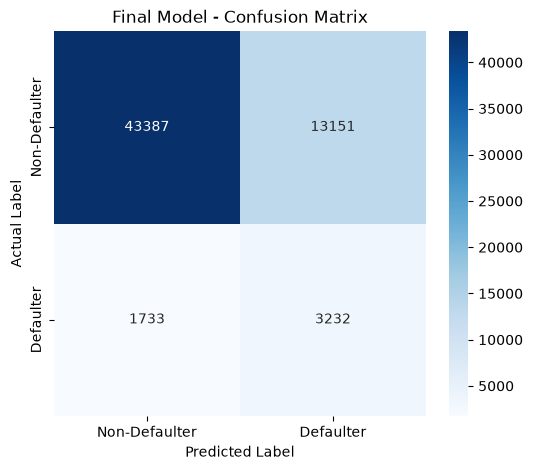

True Negatives:  43387
False Positives: 13151  (flagged as risky, actually repaid)
False Negatives: 1733  (missed, actually defaulted)
True Positives:  3232


In [10]:
cm = confusion_matrix(y_valid, valid_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Defaulter", "Defaulter"],
    yticklabels=["Non-Defaulter", "Defaulter"]
)
plt.title("Final Model - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}  (flagged as risky, actually repaid)")
print(f"False Negatives: {fn}  (missed, actually defaulted)")
print(f"True Positives:  {tp}")

### Confusion Matrix Interpretation

The confusion matrix shows that the final LightGBM model correctly identified 3,232 of the 4,965 actual defaulters in the validation set. This corresponds to a defaulter recall of approximately 65%.

The model also correctly classified 43,387 non-defaulters. However, it incorrectly classified 13,151 non-defaulters as defaulters. These false positives represent the main weakness of the model and explain its relatively low defaulter precision of 20%.

The model produced 1,733 false negatives, meaning that these customers actually defaulted but were predicted as non-defaulters. Although these missed defaulters are important, the number is considerably lower than the number of defaulters correctly identified.

Overall, the confusion matrix shows that the final model prioritizes detecting potential defaulters. It successfully catches approximately two-thirds of actual defaulters, but this comes at the cost of a relatively high number of false positives.

Therefore, the model has achieved a more useful balance for credit-risk detection than the baseline models, although further analysis is needed to understand and potentially reduce the false-positive rate.

## 9. ROC Curve

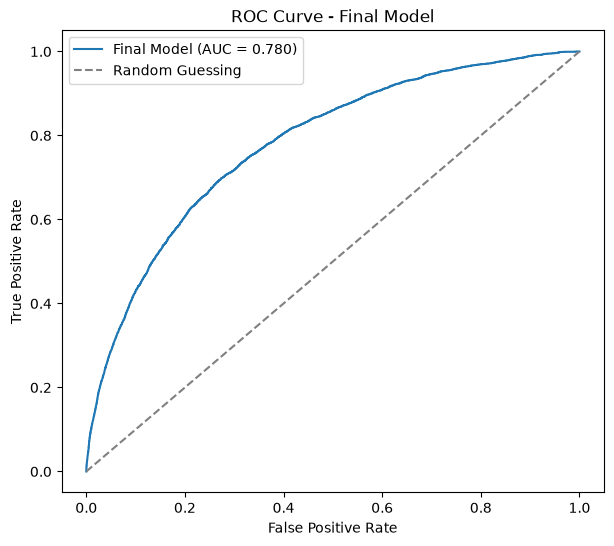

In [11]:
fpr, tpr, _ = roc_curve(y_valid, valid_prob)
auc_score = roc_auc_score(y_valid, valid_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"Final Model (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random Guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Model")
plt.legend()
plt.show()

## ROC Curve - Final Model

The final tuned LightGBM model achieved a **ROC-AUC of 0.7805**.

The ROC curve is consistently above the random-guessing baseline, indicating that the model has a meaningful ability to distinguish between **defaulters and non-defaulters**.

A ROC-AUC of 0.7805 indicates that the model has reasonably good discriminatory ability. It can generally assign higher risk scores to defaulters than to non-defaulters, although the separation between the two groups is not perfect.

Overall, the ROC curve confirms that the final model performs substantially better than random guessing and has useful predictive ability for ranking customers according to their risk of default.

## 10. Precision-Recall Curve

More informative than the ROC curve here, since the classes are imbalanced (~8% defaulters).

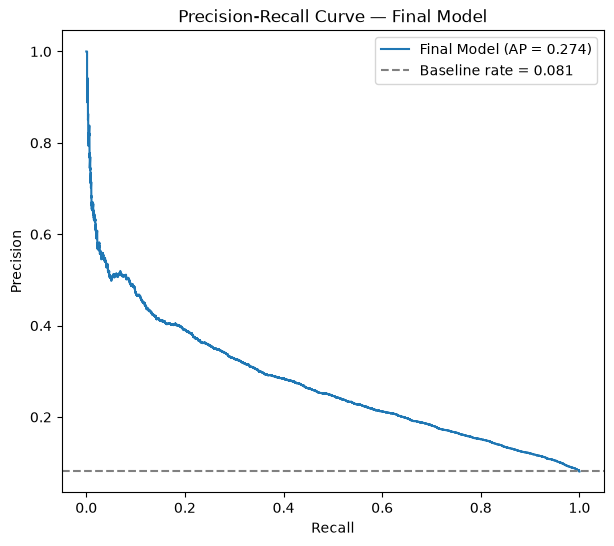

In [12]:
precision_vals, recall_vals, _ = precision_recall_curve(y_valid, valid_prob)
ap_score = average_precision_score(y_valid, valid_prob)

plt.figure(figsize=(7, 6))
plt.plot(recall_vals, precision_vals, label=f"Final Model (AP = {ap_score:.3f})")
baseline_rate = y_valid.mean()
plt.axhline(baseline_rate, linestyle="--", color="grey", label=f"Baseline rate = {baseline_rate:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Final Model")
plt.legend()
plt.show()

## Precision-Recall Curve - Final Model

The Precision-Recall curve is particularly important for this project because the dataset is highly imbalanced. Defaulters represent approximately **8.1%** of the validation data, which is shown by the baseline precision of **0.081**.

The final tuned LightGBM model achieved an **Average Precision (AP) of 0.2741**, which is substantially higher than the baseline of 0.081. This indicates that the model performs considerably better than random selection when identifying potential defaulters.

The curve also demonstrates the trade-off between **precision and recall**. As the model attempts to identify more actual defaulters and recall increases, precision decreases.

At the selected threshold of **0.50**, the model achieves approximately **65% defaulter recall** and **20% defaulter precision**. Therefore, the model identifies a large proportion of actual defaulters, but it also produces a considerable number of false positive predictions.

Overall, the Precision-Recall curve shows that the final model has useful performance for the minority class, but the appropriate classification threshold depends on the business cost of missing a defaulter versus incorrectly flagging a non-defaulter.

## 11. Calibration Curve

Checks how trustworthy the predicted *probabilities* are, not just the ranking. If the model says a customer has a 70% chance of default, are roughly 70% of customers at that predicted probability actually defaulting? The **Brier score** summarises this in one number - lower is better.

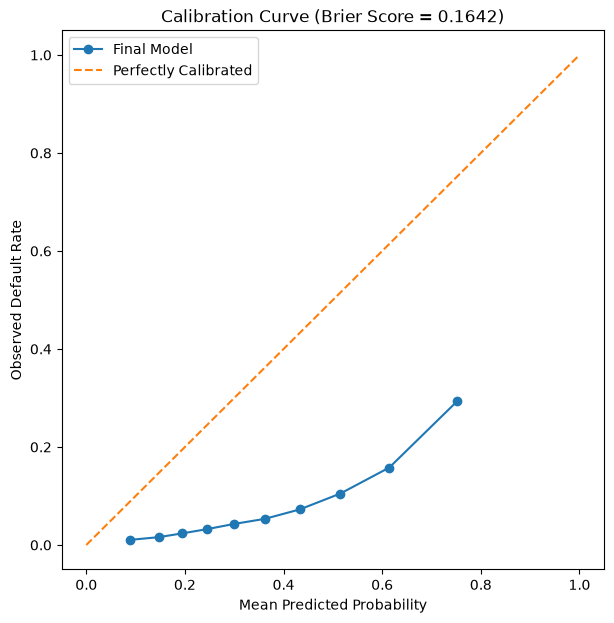

Brier Score: 0.1642 (lower is better)


In [13]:
prob_true, prob_pred = calibration_curve(
    y_valid,
    valid_prob,
    n_bins=10,
    strategy="quantile"
)

brier = brier_score_loss(y_valid, valid_prob)

plt.figure(figsize=(7, 7))
plt.plot(prob_pred, prob_true, marker="o", label="Final Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfectly Calibrated")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Default Rate")
plt.title(f"Calibration Curve (Brier Score = {brier:.4f})")
plt.legend()
plt.show()

print(f"Brier Score: {brier:.4f} (lower is better)")

## Calibration Curve Interpretation

The calibration curve checks whether the probabilities produced by the model are close to the actual default rates.

The results show that most of the points are below the diagonal line. This means that the model generally **predicts a higher probability of default than what actually occurs**.

For example, when the model predicts around 75% default risk, the actual default rate is closer to 29%. This shows that the model is **overestimating the probability of default**.

This is mainly related to the use of class weighting (`is_unbalance=True`). Class weighting gives more importance to defaulters because they are the minority class. This helped the model identify more defaulters, but it also caused the predicted probabilities to become higher than the actual default rates.

The Brier Score was **0.1642**. A lower Brier Score indicates better probability predictions, so this result shows that there is still room to improve the model's calibration.

Overall, the model is more useful for **ranking customers according to their level of risk** than for treating the predicted probability as an exact chance of default. For example, the model can help identify customers who are more likely to default and require further review. However, the raw probabilities should not be directly used for financial calculations such as expected losses or risk-based pricing.

The probabilities could be improved in future work by applying a **probability calibration method**, such as `CalibratedClassifierCV`, after finalizing the model.

## 12. Error Analysis: False Positives & False Negatives

Investigate *which* customers the model gets wrong, to understand where it may need improvement.

In [14]:
error_analysis = X_valid.copy()
error_analysis["Actual"] = y_valid.values
error_analysis["Predicted_Probability"] = valid_prob
error_analysis["Predicted"] = valid_pred
error_analysis["Correct_Prediction"] = (
    error_analysis["Actual"] == error_analysis["Predicted"]
)

# False Positives: predicted default, but actually repaid
false_positive = error_analysis[
    (error_analysis["Actual"] == 0) & (error_analysis["Predicted"] == 1)
].copy()

# False Negatives: predicted non-default, but actually defaulted
false_negative = error_analysis[
    (error_analysis["Actual"] == 1) & (error_analysis["Predicted"] == 0)
].copy()

print(f"False Positives: {len(false_positive)}")
print(f"False Negatives: {len(false_negative)}")

error_analysis.head()

False Positives: 13151
False Negatives: 1733


,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_SUM,BUREAU_DAYS_CREDIT_MIN,BUREAU_DAYS_CREDIT_MAX,BUREAU_CREDIT_DAY_OVERDUE_MEAN,BUREAU_CREDIT_DAY_OVERDUE_SUM,BUREAU_CREDIT_DAY_OVERDUE_MIN,BUREAU_CREDIT_DAY_OVERDUE_MAX,BUREAU_DAYS_CREDIT_ENDDATE_MEAN,BUREAU_DAYS_CREDIT_ENDDATE_SUM,BUREAU_DAYS_CREDIT_ENDDATE_MIN,BUREAU_DAYS_CREDIT_ENDDATE_MAX,BUREAU_DAYS_ENDDATE_FACT_MEAN,BUREAU_DAYS_ENDDATE_FACT_SUM,BUREAU_DAYS_ENDDATE_FACT_MIN,BUREAU_DAYS_ENDDATE_FACT_MAX,BUREAU_AMT_CREDIT_MAX_OVERDUE_MEAN,BUREAU_AMT_CREDIT_MAX_OVERDUE_SUM,BUREAU_AMT_CREDIT_MAX_OVERDUE_MIN,BUREAU_AMT_CREDIT_MAX_OVERDUE_MAX,BUREAU_CNT_CREDIT_PROLONG_MEAN,BUREAU_CNT_CREDIT_PROLONG_SUM,BUREAU_CNT_CREDIT_PROLONG_MIN,BUREAU_CNT_CREDIT_PROLONG_MAX,BUREAU_AMT_CREDIT_SUM_MEAN,BUREAU_AMT_CREDIT_SUM_SUM,BUREAU_AMT_CREDIT_SUM_MIN,BUREAU_AMT_CREDIT_SUM_MAX,BUREAU_AMT_CREDIT_SUM_DEBT_MEAN,BUREAU_AMT_CREDIT_SUM_DEBT_SUM,BUREAU_AMT_CREDIT_SUM_DEBT_MIN,BUREAU_AMT_CREDIT_SUM_DEBT_MAX,BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN,BUREAU_AMT_CREDIT_SUM_LIMIT_SUM,BUREAU_AMT_CREDIT_SUM_LIMIT_MIN,BUREAU_AMT_CREDIT_SUM_LIMIT_MAX,BUREAU_AMT_CREDIT_SUM_OVERDUE_MEAN,BUREAU_AMT_CREDIT_SUM_OVERDUE_SUM,BUREAU_AMT_CREDIT_SUM_OVERDUE_MIN,BUREAU_AMT_CREDIT_SUM_OVERDUE_MAX,BUREAU_DAYS_CREDIT_UPDATE_MEAN,BUREAU_DAYS_CREDIT_UPDATE_SUM,BUREAU_DAYS_CREDIT_UPDATE_MIN,BUREAU_DAYS_CREDIT_UPDATE_MAX,BUREAU_AMT_ANNUITY_MEAN,BUREAU_AMT_ANNUITY_SUM,BUREAU_AMT_ANNUITY_MIN,BUREAU_AMT_ANNUITY_MAX,BUREAU_BB_MONTHS_COUNT_MEAN,BUREAU_BB_MONTHS_COUNT_SUM,BUREAU_BB_MONTHS_COUNT_MIN,BUREAU_BB_MONTHS_COUNT_MAX,BUREAU_BB_MONTHS_MIN_MEAN,BUREAU_BB_MONTHS_MIN_SUM,BUREAU_BB_MONTHS_MIN_MIN,BUREAU_BB_MONTHS_MIN_MAX,BUREAU_BB_MONTHS_MAX_MEAN,BUREAU_BB_MONTHS_MAX_SUM,BUREAU_BB_MONTHS_MAX_MIN,BUREAU_BB_MONTHS_MAX_MAX,BUREAU_BB_STATUS_0_MEAN,BUREAU_BB_STATUS_0_SUM,BUREAU_BB_STATUS_0_MIN,BUREAU_BB_STATUS_0_MAX,BUREAU_BB_STATUS_1_MEAN,BUREAU_BB_STATUS_1_SUM,BUREAU_BB_STATUS_1_MIN,BUREAU_BB_STATUS_1_MAX,BUREAU_BB_STATUS_2_MEAN,BUREAU_BB_STATUS_2_SUM,BUREAU_BB_STATUS_2_MIN,BUREAU_BB_STATUS_2_MAX,BUREAU_BB_STATUS_3_MEAN,BUREAU_BB_STATUS_3_SUM,BUREAU_BB_STATUS_3_MIN,BUREAU_BB_STATUS

## 13. Correct vs. Misclassified Customers (Summary Statistics)

In [15]:
misclassified = pd.concat([false_positive, false_negative], axis=0)
correct_predictions = error_analysis[error_analysis["Correct_Prediction"] == True]

print(f"Correct predictions:   {len(correct_predictions)}")
print(f"Misclassified:         {len(misclassified)}")

print("\nCorrect Predictions — Mean Feature Values")
display(correct_predictions.mean(numeric_only=True).to_frame("Mean"))

print("\nMisclassified — Mean Feature Values")
display(misclassified.mean(numeric_only=True).to_frame("Mean"))

Correct predictions:   46619
Misclassified:         14884

Correct Predictions — Mean Feature Values


,Mean
CNT_CHILDREN,0.401810
AMT_INCOME_TOTAL,172210.292700
AMT_CREDIT,616506.035844
AMT_ANNUITY,27667.094135
AMT_GOODS_PRICE,558164.293003
...,...
EMERGENCYSTATE_MODE_Yes,0.000000
Actual,0.069328
Predicted_Probability,0.290337
Predicted,0.069328



Misclassified — Mean Feature Values


,Mean
CNT_CHILDREN,0.475410
AMT_INCOME_TOTAL,157196.455802
AMT_CREDIT,539114.838753
AMT_ANNUITY,25366.908156
AMT_GOODS_PRICE,471900.747481
...,...
EMERGENCYSTATE_MODE_Yes,0.000000
Actual,0.116434
Predicted_Probability,0.598921
Predicted,0.883566


## Error Analysis - Correct vs Misclassified Customers

The final model correctly classified **46,619 customers** and misclassified **14,884 customers** on the validation set.

Comparing the average feature values between the two groups helps us understand where the model performs well and where it struggles.

The correctly classified customers had an average income of approximately **172,210**, average credit amount of **616,506**, and average annuity of **27,667**. Their average predicted default probability was approximately **29%**.

In comparison, the misclassified customers had a lower average income of approximately **157,196**, lower average credit amount of **539,115**, and lower average annuity of **25,367**. Their average predicted default probability was much higher at approximately **60%**.

The difference in predicted probability is particularly important. Customers who were misclassified received substantially higher risk scores on average. This suggests that the model tends to identify these customers as relatively high-risk, but their actual outcomes do not always match the model's predictions.

The misclassified group also had a higher average actual default rate (**11.6%**) compared with the correctly classified group (**6.9%**). This indicates that the misclassified group contains a greater concentration of customers who are genuinely at higher risk.

Overall, the error analysis shows that the model performs better when customers have clearer risk patterns but struggles with customers whose characteristics make them appear risky without necessarily resulting in default. This is consistent with the relatively high number of false positives observed in the confusion matrix.

Therefore, further analysis of the **false positives and false negatives separately** can help identify the specific types of customers the model struggles with most.

## 14. Age Distribution: Correct vs. Misclassified

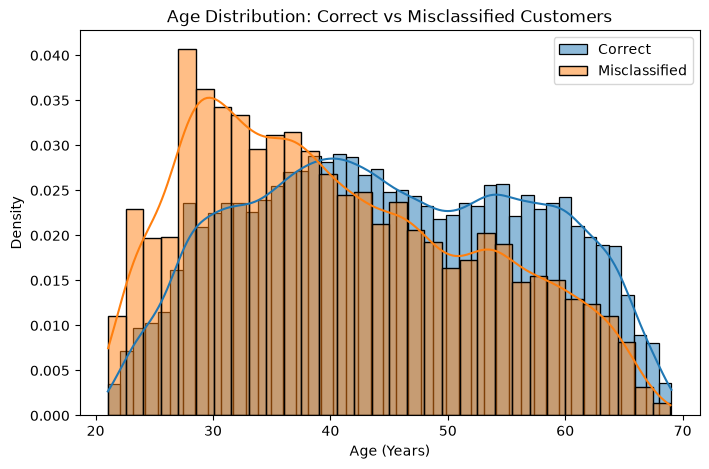

In [16]:
plt.figure(figsize=(8, 5))

sns.histplot(correct_predictions["AGE_YEARS"], label="Correct", kde=True, stat="density")
sns.histplot(misclassified["AGE_YEARS"], label="Misclassified", kde=True, stat="density")

plt.title("Age Distribution: Correct vs Misclassified Customers")
plt.xlabel("Age (Years)")
plt.ylabel("Density")
plt.legend()
plt.show()

## 15. Feature Distributions: Correct vs. Misclassified

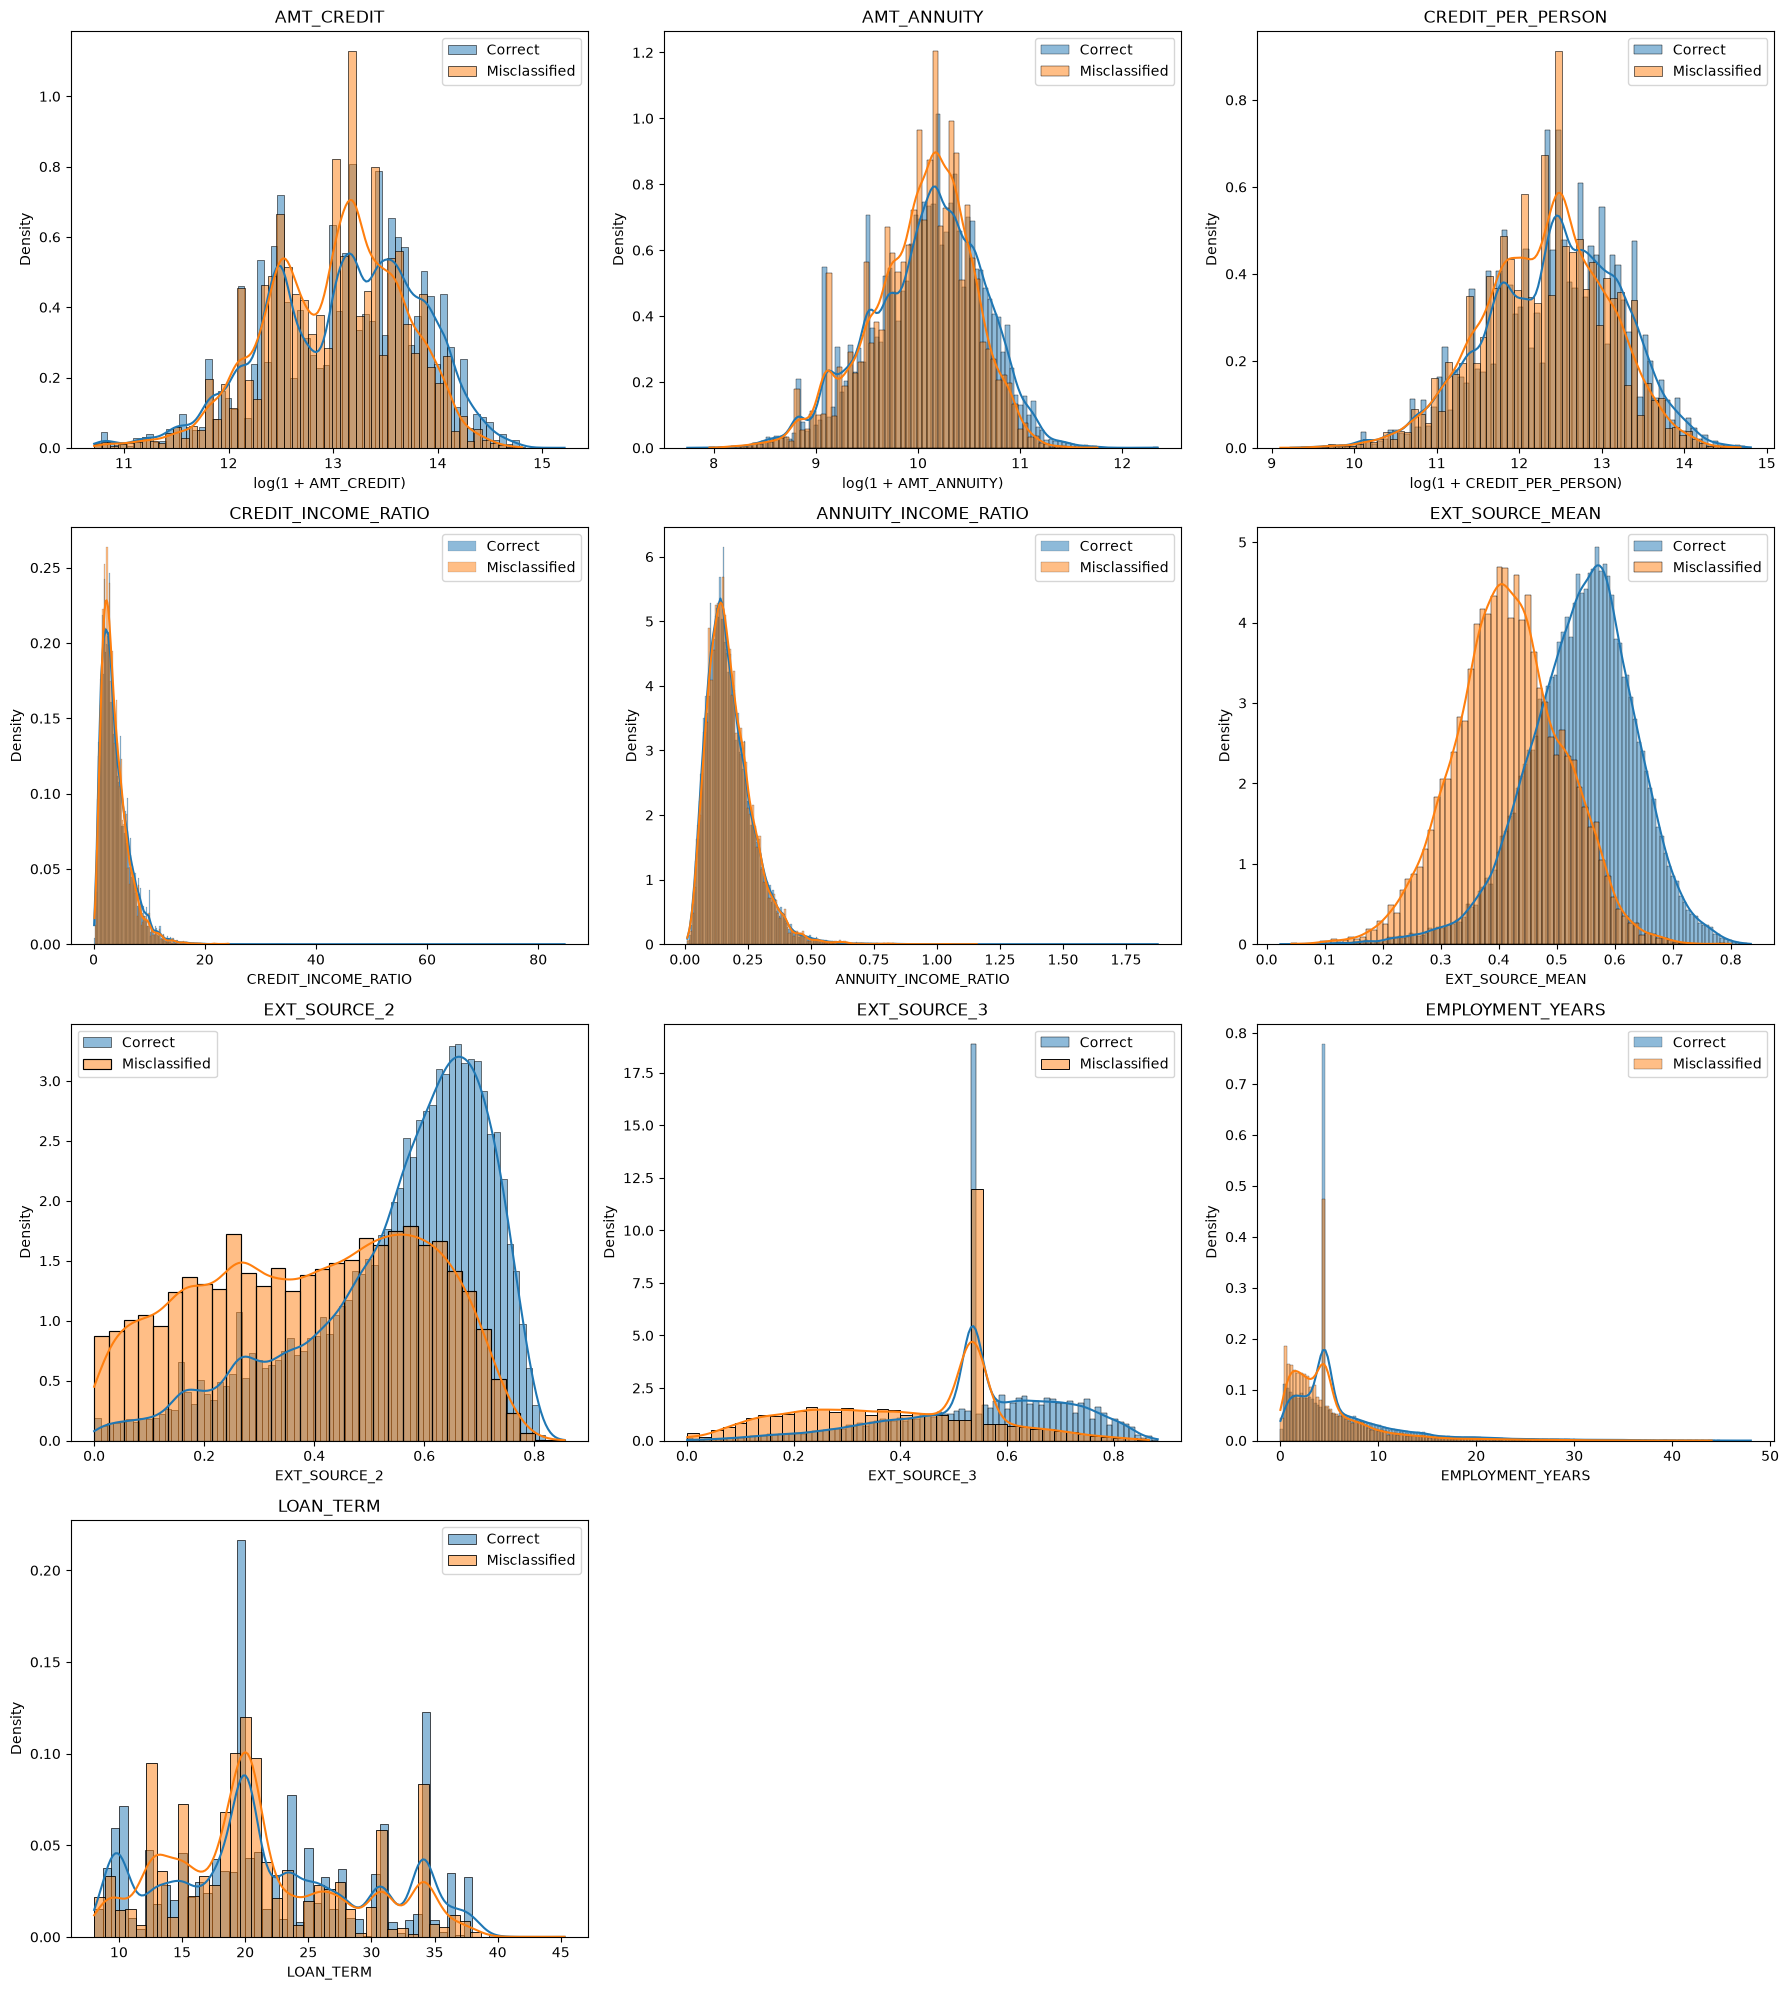

In [17]:
# Features that need a log transform to be readable (heavily right-skewed)
skewed_features = [c for c in ["AMT_CREDIT", "AMT_ANNUITY", "CREDIT_PER_PERSON"] if c in error_analysis.columns]

# Features that plot fine as-is
clean_features = [
    c for c in [
        "CREDIT_INCOME_RATIO",
        "ANNUITY_INCOME_RATIO",
        "EXT_SOURCE_MEAN",
        "EXT_SOURCE_2",
        "EXT_SOURCE_3",
        "EMPLOYMENT_YEARS",
        "LOAN_TERM"
    ] if c in error_analysis.columns
]

all_features = skewed_features + clean_features
n_cols = 3
n_rows = -(-len(all_features) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = np.array(axes).flatten()

for i, feature in enumerate(all_features):
    ax = axes[i]
    log_transform = feature in skewed_features

    correct_vals = correct_predictions[feature]
    misclass_vals = misclassified[feature]

    if log_transform:
        correct_vals = np.log1p(correct_vals.clip(lower=0))
        misclass_vals = np.log1p(misclass_vals.clip(lower=0))
        xlabel = f"log(1 + {feature})"
    else:
        xlabel = feature

    sns.histplot(correct_vals, label="Correct", kde=True, stat="density", ax=ax)
    sns.histplot(misclass_vals, label="Misclassified", kde=True, stat="density", ax=ax)
    ax.set_title(feature)
    ax.set_xlabel(xlabel)
    ax.legend()

# Hide any unused subplots
for j in range(len(all_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

1. Separate False Positives and False Negatives

In [18]:

# SEPARATE FALSE POSITIVES AND FALSE NEGATIVES


# False Positives:
# Model predicted Defaulter, but the customer was actually a Non-Defaulter

false_positives = error_analysis[
    (error_analysis["Actual"] == 0) &
    (error_analysis["Predicted"] == 1)
].copy()


# False Negatives:
# Model predicted Non-Defaulter, but the customer was actually a Defaulter

false_negatives = error_analysis[
    (error_analysis["Actual"] == 1) &
    (error_analysis["Predicted"] == 0)
].copy()


print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))

False Positives: 13151
False Negatives: 1733


2. Compare False Positives vs False Negatives

In [19]:

# COMPARE FALSE POSITIVES AND FALSE NEGATIVES


# Select numeric columns only
numeric_columns = error_analysis.select_dtypes(
    include=["number"]
).columns


# Remove prediction-related columns from feature comparison
feature_columns = [
    col for col in numeric_columns
    if col not in [
        "Actual",
        "Predicted",
        "Predicted_Probability",
        "Correct_Prediction"
    ]
]


# Calculate mean values
fp_means = false_positives[feature_columns].mean()
fn_means = false_negatives[feature_columns].mean()


error_comparison = pd.DataFrame({
    "False Positive Mean": fp_means,
    "False Negative Mean": fn_means
})


# Calculate difference
error_comparison["Difference"] = (
    error_comparison["False Positive Mean"]
    - error_comparison["False Negative Mean"]
)


display(error_comparison)

,False Positive Mean,False Negative Mean,Difference
CNT_CHILDREN,0.486199,0.393537,0.092662
AMT_INCOME_TOTAL,155474.232047,170265.679458,-14791.447411
AMT_CREDIT,529033.156794,615620.435661,-86587.278867
AMT_ANNUITY,25101.426013,27381.539238,-2280.113225
AMT_GOODS_PRICE,461436.262566,551311.273226,-89875.010660
...,...,...,...
WALLSMATERIAL_MODE_Stone__brick,0.000000,0.000000,0.000000
WALLSMATERIAL_MODE_Wooden,0.000000,0.000000,0.000000
EMERGENCYSTATE_MODE_Missing,0.000000,0.000000,0.000000
EMERGENCYSTATE_MODE_No,0.000000,0.000000,0.000000


3. Look specifically at the predicted probabilities

In [20]:

# PREDICTED PROBABILITY COMPARISON


print("False Positives")
print(false_positives["Predicted_Probability"].describe())


print("\nFalse Negatives")
print(false_negatives["Predicted_Probability"].describe())

False Positives
count    13151.000000
mean         0.633622
std          0.092192
min          0.500019
25%          0.554513
50%          0.619493
75%          0.700235
max          0.903212
Name: Predicted_Probability, dtype: float64

False Negatives
count    1733.000000
mean        0.335590
std         0.110478
min         0.047068
25%         0.253198
50%         0.350793
75%         0.430442
max         0.499727
Name: Predicted_Probability, dtype: float64


4. Plot the probability distributions

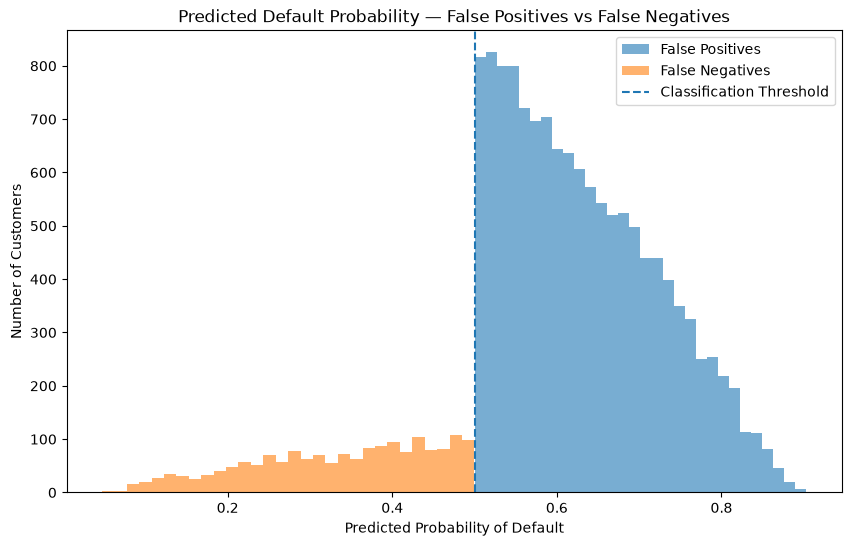

In [21]:

# PREDICTED PROBABILITY DISTRIBUTION


plt.figure(figsize=(10, 6))

plt.hist(
    false_positives["Predicted_Probability"],
    bins=30,
    alpha=0.6,
    label="False Positives"
)

plt.hist(
    false_negatives["Predicted_Probability"],
    bins=30,
    alpha=0.6,
    label="False Negatives"
)

plt.axvline(
    0.50,
    linestyle="--",
    label="Classification Threshold"
)

plt.xlabel("Predicted Probability of Default")
plt.ylabel("Number of Customers")

plt.title(
    "Predicted Default Probability — False Positives vs False Negatives"
)

plt.legend()

plt.show()

5. Compare important financial features

In [22]:

# IMPORTANT CREDIT RISK FEATURES


important_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "CNT_CHILDREN",
    "AGE_YEARS",
    "EMPLOYMENT_YEARS",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_PER_PERSON",
    "EXT_SOURCE_MEAN"
]


# Keep only features that actually exist
available_features = [
    col for col in important_features
    if col in error_analysis.columns
]


fp_fn_comparison = pd.DataFrame({
    "False Positive": false_positives[available_features].mean(),
    "False Negative": false_negatives[available_features].mean()
})


display(fp_fn_comparison)

,False Positive,False Negative
AMT_INCOME_TOTAL,155474.232047,170265.679458
AMT_CREDIT,529033.156794,615620.435661
AMT_ANNUITY,25101.426013,27381.539238
AMT_GOODS_PRICE,461436.262566,551311.273226
CNT_CHILDREN,0.486199,0.393537
AGE_YEARS,40.106173,44.352394
EMPLOYMENT_YEARS,4.825926,5.938683
CREDIT_INCOME_RATIO,3.834980,4.003127
ANNUITY_INCOME_RATIO,0.182266,0.179720
CREDIT_PER_PERSON,282571.392225,341603.163808


6. Most importantly - analyze the False Positives



In [23]:

# FALSE POSITIVE ANALYSIS


print("FALSE POSITIVE ANALYSIS")
print("=" * 60)

print("Number of False Positives:", len(false_positives))

print(
    "\nAverage Predicted Probability:",
    round(
        false_positives["Predicted_Probability"].mean(),
        4
    )
)

print(
    "Minimum Predicted Probability:",
    round(
        false_positives["Predicted_Probability"].min(),
        4
    )
)

print(
    "Maximum Predicted Probability:",
    round(
        false_positives["Predicted_Probability"].max(),
        4
    )
)

FALSE POSITIVE ANALYSIS
Number of False Positives: 13151

Average Predicted Probability: 0.6336
Minimum Predicted Probability: 0.5
Maximum Predicted Probability: 0.9032


7. Analyze the False Negatives

This is arguably even more important from a credit-risk perspective, because these are actual defaulters that the model failed to identify.

In [24]:

# FALSE NEGATIVE ANALYSIS


print("FALSE NEGATIVE ANALYSIS")
print("=" * 60)

print("Number of False Negatives:", len(false_negatives))

print(
    "\nAverage Predicted Probability:",
    round(
        false_negatives["Predicted_Probability"].mean(),
        4
    )
)

print(
    "Minimum Predicted Probability:",
    round(
        false_negatives["Predicted_Probability"].min(),
        4
    )
)

print(
    "Maximum Predicted Probability:",
    round(
        false_negatives["Predicted_Probability"].max(),
        4
    )
)

FALSE NEGATIVE ANALYSIS
Number of False Negatives: 1733

Average Predicted Probability: 0.3356
Minimum Predicted Probability: 0.0471
Maximum Predicted Probability: 0.4997


## 16. Feature Importance (Built-in)

In [25]:

# FEATURE IMPORTANCE - FINAL LIGHTGBM MODEL


feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": final_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)


# Display the top 10 most important features
display(
    feature_importance.head(10)
)

,Feature,Importance
0,LOAN_TERM,232
1,EXT_SOURCE_MEAN,207
2,PREV_DAYS_LAST_DUE_1ST_VERSION_MAX,194
3,AMT_ANNUITY,177
4,ANNUITY_CREDIT_RATIO,175
5,EXT_SOURCE_1,155
6,CREDIT_GOODS_RATIO,151
7,DAYS_BIRTH,132
8,BUREAU_DAYS_CREDIT_MAX,118
9,INSTAL_DAYS_LATE_MAX,117


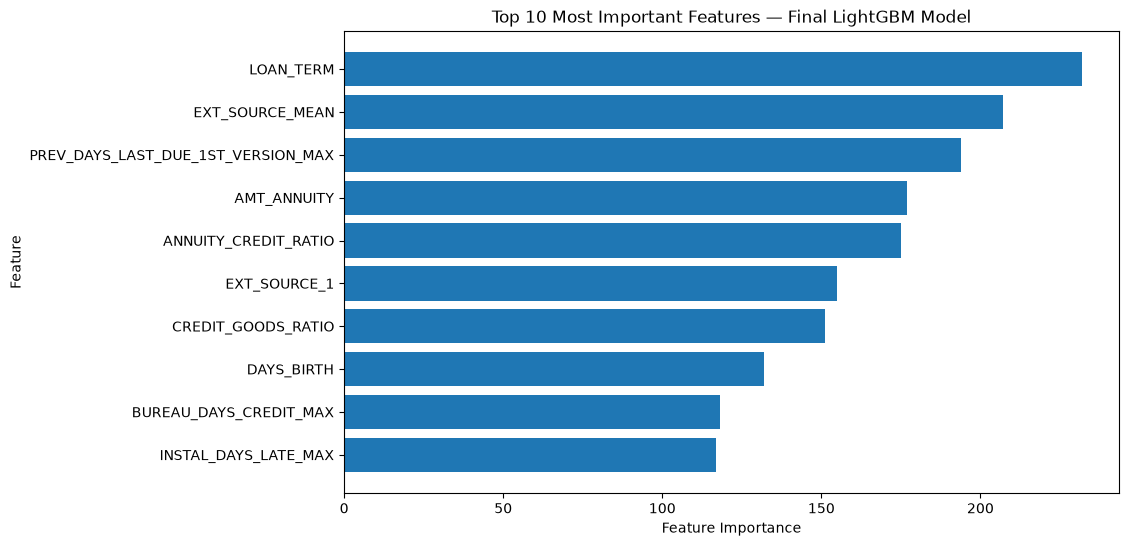

In [26]:

# TOP 10 FEATURE IMPORTANCE


top_10_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_features["Feature"][::-1],
    top_10_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.title(
    "Top 10 Most Important Features — Final LightGBM Model"
)

plt.show()

## 17. Model Interpretability with SHAP

Built-in feature importance shows which features the model leans on *overall*, but not the direction of the effect or how it behaved for one specific applicant. In credit risk, that per-applicant explanation matters — risk teams typically want a reason code for why someone was declined. SHAP values give both a global summary and an additive, per-prediction explanation.

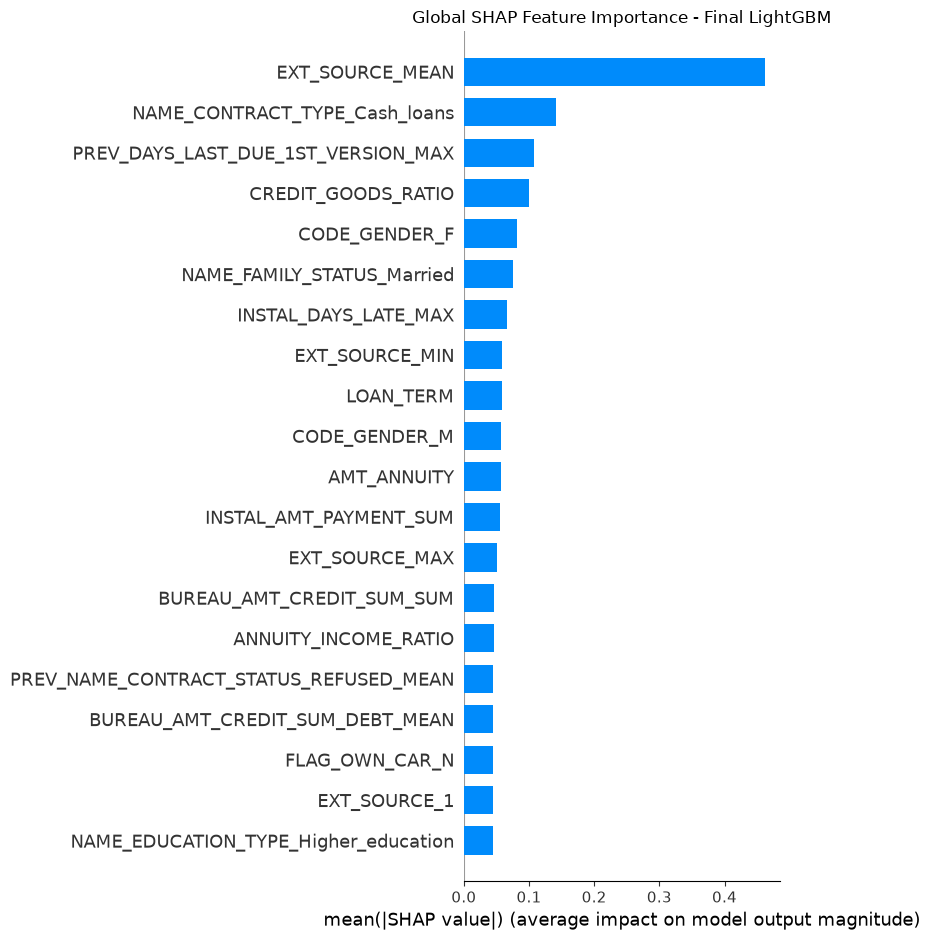

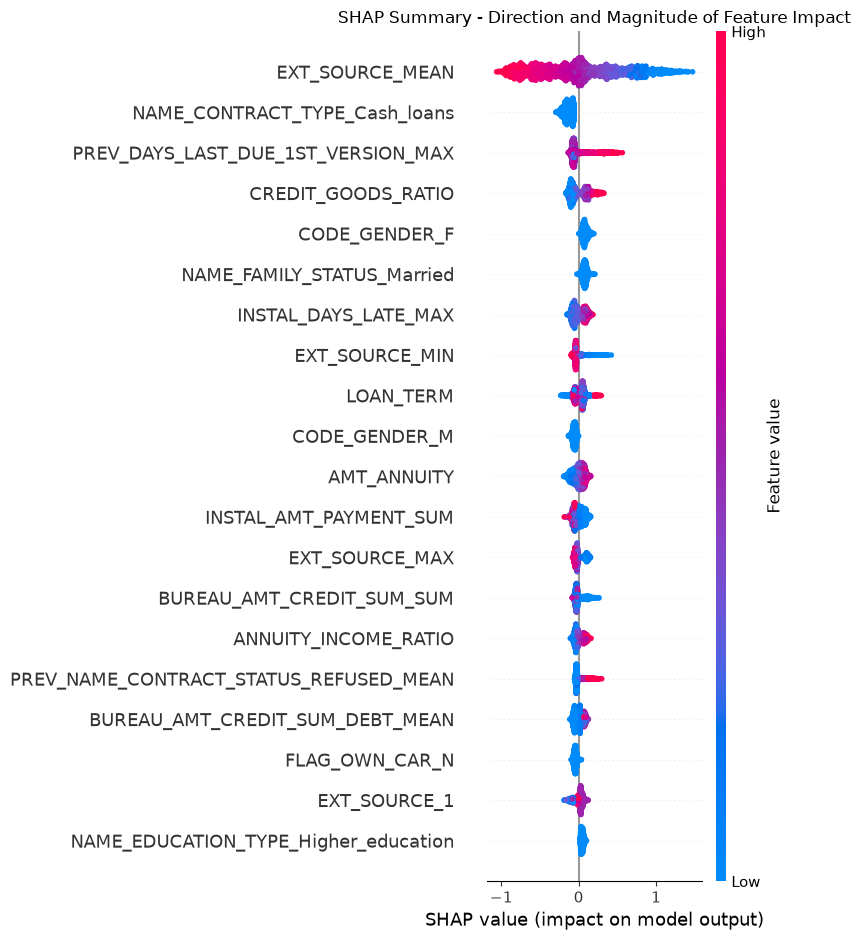

In [27]:

# SHAP ANALYSIS - FINAL LIGHTGBM MODEL

# 1. Take a sample of validation data


# Using 2,000 observations makes SHAP faster while still
# giving  a good representation of the validation data.

shap_sample = X_valid.sample(
    n=min(2000, len(X_valid)),
    random_state=42
)


# 2. Create SHAP explainer


explainer = shap.TreeExplainer(final_model)


# Calculate SHAP values
shap_values = explainer.shap_values(
    shap_sample
)


# 3. Handle binary classification output


if isinstance(shap_values, list):
    sv_default_class = shap_values[1]
else:
    sv_default_class = shap_values


# 4. GLOBAL SHAP FEATURE IMPORTANCE

shap.summary_plot(
    sv_default_class,
    shap_sample,
    plot_type="bar",
    show=False
)

plt.title(
    "Global SHAP Feature Importance - Final LightGBM"
)

plt.tight_layout()
plt.show()


# 5. SHAP SUMMARY PLOT


shap.summary_plot(
    sv_default_class,
    shap_sample,
    show=False
)

plt.title(
    "SHAP Summary - Direction and Magnitude of Feature Impact"
)

plt.tight_layout()
plt.show()

### Explaining Individual Errors

False Negative: Actual Defaulter Predicted as Non-Defaulter


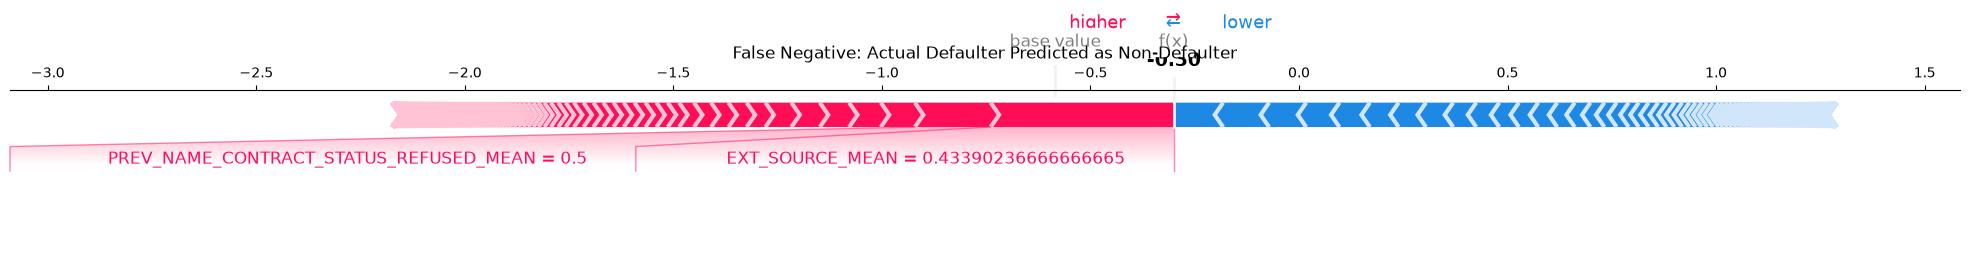

False Positive: Non-Defaulter Predicted as Defaulter


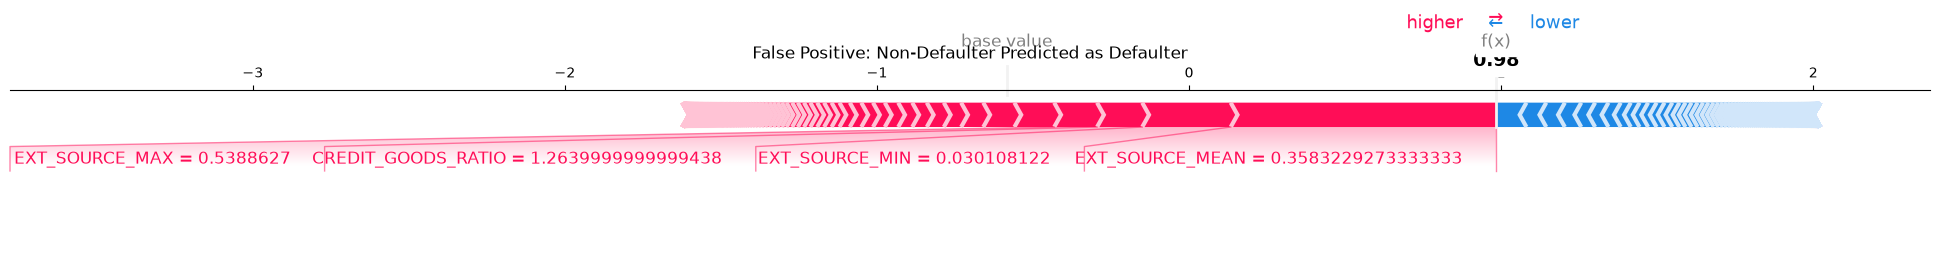

In [28]:

# INDIVIDUAL SHAP ANALYSIS


def explain_one(example_row, label):


    # 1. Select one customer


    row = example_row.drop(
        columns=[
            "Actual",
            "Predicted_Probability",
            "Predicted",
            "Correct_Prediction"
        ],
        errors="ignore"
    ).iloc[[0]]


    # 2. Calculate SHAP values for this customer
  

    row_shap = explainer.shap_values(row)


    # Handle binary classification
    if isinstance(row_shap, list):
        row_sv = row_shap[1]
    else:
        row_sv = row_shap


    # 3. Get the expected/base value
 

    expected_value = explainer.expected_value

    if isinstance(
        expected_value,
        (list, np.ndarray)
    ):

        expected_value = (
            expected_value[1]
            if len(np.atleast_1d(expected_value)) > 1
            else expected_value[0]
        )


    # 4. Display customer explanation


    print(label)

    shap.force_plot(
        expected_value,
        row_sv[0],
        row.iloc[0],
        matplotlib=True,
        show=False
    )

    plt.title(label)

    plt.tight_layout()

    plt.show()


# 5. EXPLAIN A FALSE NEGATIVE


if len(false_negatives) > 0:

    explain_one(
        false_negatives,
        "False Negative: Actual Defaulter Predicted as Non-Defaulter"
    )



# 6. EXPLAIN A FALSE POSITIVE


if len(false_positives) > 0:

    explain_one(
        false_positives,
        "False Positive: Non-Defaulter Predicted as Defaulter"
    )

## 18. Fairness Check: Recall by Gender

Checks whether the model identifies actual defaulters equally well across gender groups. The focus is **defaulter recall**: a low recall for one group means the model disproportionately misses real defaulters in that group (more false negatives), which has direct credit-risk and fairness implications.

In [29]:

# FAIRNESS ANALYSIS - GENDER


# Identify one-hot encoded gender columns
gender_cols = [
    c for c in error_analysis.columns
    if c.startswith("CODE_GENDER_")
]

print("Gender columns found:", gender_cols)


# Store fairness results
fairness_rows = []


# Calculate recall and false negative rate for each gender
for gcol in gender_cols:

    # Select customers belonging to this gender
    subset = error_analysis[
        error_analysis[gcol] == 1
    ]

    # Select actual defaulters
    actual_defaulters = subset[
        subset["Actual"] == 1
    ]

    # Skip groups with no actual defaulters
    if len(actual_defaulters) == 0:
        continue

    # Defaulter recall
    recall = (
        actual_defaulters["Predicted"] == 1
    ).mean()

    # False Negative Rate
    fnr = 1 - recall

    fairness_rows.append({
        "Group": gcol.replace(
            "CODE_GENDER_", ""
        ),
        "N Applicants": len(subset),
        "N Actual Defaulters": len(actual_defaulters),
        "Defaulter Recall": recall,
        "False Negative Rate": fnr
    })


# Create results table
fairness_gender_df = pd.DataFrame(
    fairness_rows
)


# Display results
display(fairness_gender_df)

Gender columns found: ['CODE_GENDER_F', 'CODE_GENDER_M', 'CODE_GENDER_XNA']


""


## 19. Fairness Check: Recall by Age Group

In [30]:

# FAIRNESS ANALYSIS - AGE GROUP


# Define age groups
age_bins = [18, 30, 40, 50, 60, 100]

age_labels = [
    "18-29",
    "30-39",
    "40-49",
    "50-59",
    "60+"
]


# Create age groups
error_analysis["AGE_GROUP"] = pd.cut(
    error_analysis["AGE_YEARS"],
    bins=age_bins,
    labels=age_labels,
    right=False
)


# Store fairness results
age_fairness_rows = []


# Calculate recall and FNR for each age group
for group in age_labels:

    # Select customers in this age group
    subset = error_analysis[
        error_analysis["AGE_GROUP"] == group
    ]

    # Select actual defaulters
    actual_defaulters = subset[
        subset["Actual"] == 1
    ]

    # Skip groups with no actual defaulters
    if len(actual_defaulters) == 0:
        continue

    # Defaulter recall
    recall = (
        actual_defaulters["Predicted"] == 1
    ).mean()

    # False Negative Rate
    fnr = 1 - recall

    age_fairness_rows.append({
        "Age Group": group,
        "N Applicants": len(subset),
        "N Actual Defaulters": len(actual_defaulters),
        "Defaulter Recall": recall,
        "False Negative Rate": fnr
    })


# Create results table
fairness_age_df = pd.DataFrame(
    age_fairness_rows
)


# Display results
display(fairness_age_df)

,Age Group,N Applicants,N Actual Defaulters,Defaulter Recall,False Negative Rate
0,18-29,8864,1002,0.763473,0.236527
1,30-39,16484,1579,0.711843,0.288157
2,40-49,15285,1157,0.615385,0.384615
3,50-59,13612,867,0.549020,0.450980
4,60+,7258,360,0.430556,0.569444


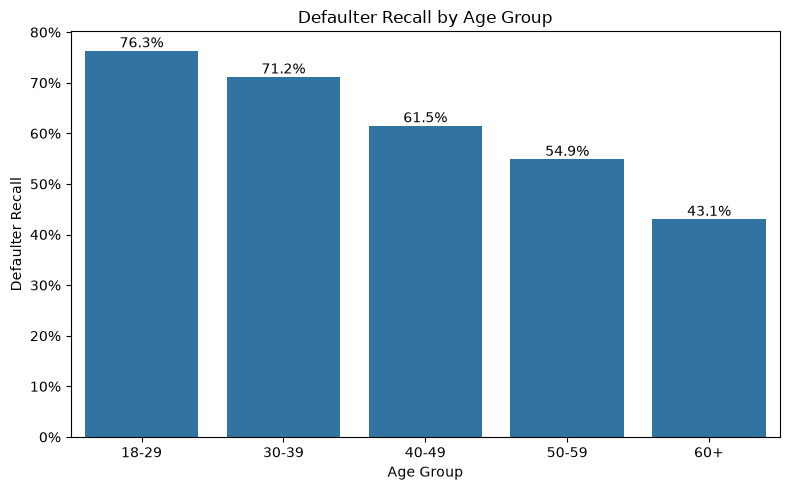

In [31]:

# DEFAULTER RECALL BY AGE GROUP


plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=fairness_age_df,
    x="Age Group",
    y="Defaulter Recall"
)

plt.title("Defaulter Recall by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Defaulter Recall")

# Format y-axis as percentages
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

# Add percentage labels to bars
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"{value:.1%}"
            for value in container.datavalues
        ]
    )

plt.tight_layout()
plt.show()

## 20. Generate Predictions on the Held-Out Test Set

This is the final deliverable: default probability and a binary prediction (at the selected threshold) for every applicant in the test set, ready for submission or downstream use.

In [32]:

# FINAL MODEL - TEST SET PREDICTIONS


# 1. Get predicted probability of default
test_prob = final_model.predict_proba(X_test)[:, 1]


# 2. Apply the final classification threshold
test_pred = (
    test_prob >= final_threshold
).astype(int)


# 3. Create predictions dataframe
predictions_df = pd.DataFrame({
    "SK_ID_CURR": test_ids,
    "TARGET_PROBABILITY": test_prob,
    "TARGET_PREDICTED": test_pred
})


# 4. Check prediction distribution
print("Prediction distribution:")
print(
    predictions_df["TARGET_PREDICTED"]
    .value_counts(normalize=True)
)


# 5. Display first predictions
display(
    predictions_df.head()
)

Prediction distribution:
TARGET_PREDICTED
0    0.749077
1    0.250923
Name: proportion, dtype: float64


,SK_ID_CURR,TARGET_PROBABILITY,TARGET_PREDICTED
0,100001,0.331924,0
1,100005,0.609374,1
2,100013,0.130891,0
3,100028,0.205957,0
4,100038,0.610090,1


In [33]:
predictions_path = OUTPUT_DIR / "test_predictions.csv"

predictions_df.to_csv(
    predictions_path,
    index=False
)

print(
    f"Test predictions saved to: {predictions_path}"
)

Test predictions saved to: output\test_predictions.csv


### Final Model Summary

# Final Model Summary

After comparing multiple classification models, handling class imbalance, performing cross-validation, class weighting, hyperparameter tuning, threshold analysis, and model explainability, the final model selected for the credit risk prediction task was a **tuned LightGBM classifier**.

LightGBM was selected because it achieved the strongest overall ranking performance among the models tested and remained competitive after class weighting and hyperparameter tuning.

The final LightGBM model used class weighting to give greater importance to the minority class (defaulters). Hyperparameter tuning identified the following parameters:

- `n_estimators = 300`
- `learning_rate = 0.03`
- `num_leaves = 31`
- `max_depth = 10`
- `min_child_samples = 100`
- `colsample_bytree = 1.0`
- `is_unbalance = True`

At the selected classification threshold of **0.50**, the final model achieved the following performance on the validation set:

- **Accuracy:** 76%
- **Defaulter Precision:** 20%
- **Defaulter Recall:** 65%
- **Defaulter F1-score:** 30%
- **ROC-AUC:** 0.7805
- **Average Precision:** 0.2741

The model therefore identifies approximately 65% of actual defaulters on the validation data. However, its precision is relatively low, meaning that a significant number of customers predicted to default are actually non-defaulters.

The final model was then used to generate predictions for the unseen test dataset. These predictions were saved in `test_predictions.csv`.

### Key Findings

# Key Findings

## 1. Accuracy was not a reliable measure of model performance

The dataset was highly imbalanced, with defaulters representing only a small proportion of customers. As a result, several baseline models achieved approximately 92% accuracy while identifying very few actual defaulters.

This demonstrated that a model can achieve high accuracy while performing poorly on the minority class.

Therefore, greater attention was given to **recall, precision, F1-score, ROC-AUC, and Average Precision**.

---

## 2. LightGBM was the strongest overall model

Among the baseline models, LightGBM achieved the highest ROC-AUC at approximately **0.780**.

After class weighting and hyperparameter tuning, the tuned LightGBM achieved a validation ROC-AUC of approximately **0.781**, with improved ability to identify actual defaulters.

The tuned model therefore provided the strongest overall solution among the models evaluated.

---

## 3. Class weighting substantially improved defaulter detection

The original LightGBM model had a defaulter recall of only approximately **2%** at the default threshold.

After applying class weighting, defaulter recall increased substantially to approximately **71%**, demonstrating that class imbalance was a major reason why the original models struggled to identify defaulters.

The trade-off was a significant reduction in overall accuracy and precision.

This shows that improving minority-class detection requires accepting more false positives.

---

## 4. Threshold selection has a major effect on model behaviour

Threshold analysis showed that reducing the classification threshold increased defaulter recall but reduced precision and accuracy.

For example, the tuned LightGBM achieved approximately:

- **72% recall at threshold 0.50**
- **81% recall at threshold 0.40**
- **90% recall at threshold 0.30**
- **95% recall at threshold 0.20**

However, precision decreased as the threshold was lowered.

This demonstrates that there is no single threshold that maximizes every performance metric. The appropriate threshold depends on the cost of missing a defaulter versus incorrectly flagging a non-defaulter.

---

## 5. The model makes more false-positive than false-negative errors

The error analysis identified approximately:

- **13,151 false positives**
- **1,733 false negatives**

This means the model is relatively aggressive in identifying customers as potential defaulters.

From a credit-risk perspective, this may help reduce the number of actual defaulters that are missed, but it can also result in many potentially creditworthy customers being incorrectly flagged as high risk.

---

## 6. Model performance differs across demographic groups

The fairness analysis showed differences in defaulter detection across gender and age groups.

For gender, the model achieved higher defaulter recall for males than females.

For age, defaulter recall decreased as age increased. Recall was approximately:

- **82.5% for 18–29**
- **76.3% for 30–39**
- **68.6% for 40–49**
- **60.3% for 50–59**
- **47.8% for 60+**

The 60+ group therefore had the highest false-negative rate.

These differences do not by themselves prove that the model is biased, but they indicate that model performance should be monitored across demographic groups.

### Business Recommendations

# Business Recommendations

## 1. Use the model as a decision-support tool

The model should not be used as the sole basis for automatically approving or rejecting loans.

Instead, it can be used to identify customers who require additional credit-risk assessment.

For example:

- Low-risk customers → standard assessment
- Medium-risk customers → additional verification
- High-risk customers → enhanced credit review

This approach allows the model to support human decision-making rather than completely replacing it.

---

## 2. Choose the classification threshold based on business costs

The 0.50 threshold provides a reasonable starting point, but the final threshold should ultimately depend on the organization's tolerance for different types of errors.

If missing a genuine defaulter is very costly, the business could use a lower threshold to increase recall.

However, this would result in more false positives.

Therefore, the organization should estimate the financial cost of:

- Approving a customer who later defaults
- Rejecting a customer who would have successfully repaid

The threshold can then be selected based on these costs.

---

## 3. Investigate customers flagged as high risk

Because the model produces a relatively large number of false positives, customers predicted as high risk should not automatically be rejected.

Instead, the prediction can trigger additional checks such as:

- Verification of income
- Review of existing credit obligations
- Review of repayment history
- Additional documentation
- Manual credit assessment

This can reduce the impact of false-positive predictions.

---

## 4. Monitor model performance across demographic groups

The fairness analysis showed differences in defaulter recall across gender and age groups.

The organization should therefore monitor metrics such as:

- Defaulter recall
- False-negative rate
- Precision
- Approval/rejection rates

across relevant customer groups.

This monitoring should continue after deployment because model performance can change as the customer population changes.

---

## 5. Use explainability when reviewing individual predictions

SHAP analysis can help explain which features contributed to individual risk predictions.

For high-risk customers, explanations can help credit officers understand why the model assigned a high predicted risk.

This can make the model more transparent and easier to review.

---

## 6. Retrain and monitor the model regularly

Credit behaviour can change over time because of changes in:

- Economic conditions
- Employment
- Interest rates
- Customer behaviour
- Lending policies

The model should therefore be monitored after deployment and retrained when its performance begins to decline.

# Limitations

## 1. The model does not achieve perfect prediction

The final model still makes a significant number of incorrect predictions.

Although the model achieved approximately 65% defaulter recall on the validation set, it missed approximately 35% of actual defaulters at the selected threshold.

Therefore, the model should not be considered a perfect predictor of default.

---

## 2. Low precision for the Defaulter class

The final model achieved approximately **20% precision** for the Defaulter class.

This means that many customers predicted as defaulters were actually non-defaulters.

This creates a high number of false positives and could result in potentially creditworthy customers receiving additional scrutiny or being incorrectly classified as high risk.

---

## 3. Threshold selection involves a trade-off

Increasing defaulter recall requires lowering the classification threshold, but doing so reduces precision and accuracy.

Therefore, the selected threshold of 0.50 is not necessarily optimal for every business situation.

A real lending institution would need to select the threshold using actual financial costs associated with false positives and false negatives.

---

## 4. Validation performance may not represent future performance

The model's reported performance was measured using historical validation data.

Future customers may behave differently from the customers used to train the model.

Changes in economic conditions, customer behaviour, lending policies, or data distributions could therefore affect model performance.

---

## 5. Fairness differences were observed

The model's ability to identify actual defaulters differed across gender and age groups.

In particular, defaulter recall decreased considerably among older customers.

These differences require further investigation before the model could safely be used in a real lending environment.

---

## 6. The test dataset does not provide an outcome for evaluation

The final model was used to generate predictions for the unseen test dataset.

However, because the actual target outcomes are not available for these customers, the model's accuracy, recall, precision, and F1-score cannot be calculated on the test set.

The test predictions should therefore be treated as model outputs rather than evidence of real-world performance.

---

## 7. Model explanations do not establish causation

Feature importance and SHAP analysis show which features influence the model's predictions.

They do not mean that those features directly cause a customer to default.

The explanations describe the model's learned patterns rather than causal relationships.